In [5]:
# ============================================================
# EXPERIMENT 3
# Batch & Mini-Batch Gradient Descent vs sklearn
# ============================================================

# NumPy for arrays and matrix calculations
import numpy as np

# Pandas for reading and handling the CSV dataset
import pandas as pd

# Matplotlib for plotting the loss curve
import matplotlib.pyplot as plt

# sklearn Linear Regression
from sklearn.linear_model import LinearRegression

# Function to split data into training and testing sets
from sklearn.model_selection import train_test_split

# StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

# Mean Squared Error for evaluating the model
from sklearn.metrics import mean_squared_error

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# ============================================================
# STEP 2: LOAD DATA
# ============================================================

# Read the 50,000-row dataset
df = pd.read_csv("/content/placement_predict_50k Dataset (1) (1).csv")

# Display first 5 rows
print(df.head())

# Display dataset shape
print("Dataset shape:", df.shape)

   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    DataScience    Yes   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Publications  \
0                No       6.02       6.54  ...             0   
1               Yes       5.84       5.12  ...             0   
2                No       4.91       5.29  ...             0   
3                No       7.67       8.03  ...             0   
4                No       8.14       8.97  ...             1   

   AptitudeTestScore  SoftSkillsRating  CodingTestScore  MockInterviewScore  \
0               66.7               2.2             49.4                47.8   


In [8]:
# ============================================================
# STEP 3: SELECT FEATURES AND TARGET
# ============================================================

# Input features
FEATURES = [
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore",
    "ExtraCurricular"
]

# Target variable
TARGET = "Salary Package"

# Keep only selected features and target
data = df[FEATURES + [TARGET]].copy()

print(data.head())

   CGPA  AttendancePercent  Internships  Projects  Workshops  Certifications  \
0  6.29               73.3            1         2        NaN               2   
1  5.23               54.5            0         1        0.0               1   
2  5.52               77.6            1         3        1.0               1   
3  7.51               68.8            1         2        1.0               2   
4  8.65               95.8            2         3        NaN               4   

   Publications  AptitudeTestScore  SoftSkillsRating  CodingTestScore  \
0             0               66.7               2.2             49.4   
1             0               48.2               2.4             26.7   
2             0               73.8               2.8             67.7   
3             0               69.8               2.7             66.9   
4             1               73.1               2.1             71.7   

   MockInterviewScore  ExtraCurricular  Salary Package  
0                47.8  

In [9]:
# ============================================================
# STEP 4: HANDLE MISSING VALUES
# ============================================================

# Replace missing values with the median
# of each respective feature
data[FEATURES] = data[FEATURES].fillna(
    data[FEATURES].median()
)

# Check for missing values
print(data[FEATURES].isnull().sum())

CGPA                  0
AttendancePercent     0
Internships           0
Projects              0
Workshops             0
Certifications        0
Publications          0
AptitudeTestScore     0
SoftSkillsRating      0
CodingTestScore       0
MockInterviewScore    0
ExtraCurricular       0
dtype: int64


In [10]:
# ============================================================
# STEP 5: CREATE INPUT X AND TARGET y
# ============================================================

# X contains all input features
X = data[FEATURES].values

# y contains Salary Package
# reshape(-1,1) converts it into a column vector
y = data[TARGET].values.reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 12)
y shape: (50000, 1)


In [11]:
# ============================================================
# STEP 6: TRAIN / TEST SPLIT
# ============================================================

# 80% data -> training
# 20% data -> testing
# random_state=42 -> same split every time

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (40000, 12)
X_test: (10000, 12)
y_train: (40000, 1)
y_test: (10000, 1)


In [12]:
# ============================================================
# STEP 7: FEATURE SCALING
# ============================================================

# Create StandardScaler
scaler = StandardScaler()

# Fit scaler only on training data
X_train_s = scaler.fit_transform(X_train)

# Apply the same scaler to test data
X_test_s = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [13]:
# ============================================================
# STEP 8: ADD BIAS COLUMN
# ============================================================

# Get number of training samples and features
n_samples, n_features = X_train_s.shape

# Add a column of 1s for the intercept/bias
X_train_b = np.hstack([
    np.ones((n_samples, 1)),
    X_train_s
])

# Add bias column to test data
X_test_b = np.hstack([
    np.ones((X_test_s.shape[0], 1)),
    X_test_s
])

print("X_train_b shape:", X_train_b.shape)
print("X_test_b shape:", X_test_b.shape)

X_train_b shape: (40000, 13)
X_test_b shape: (10000, 13)


In [14]:
# ============================================================
# STEP 9: MEAN SQUARED ERROR
# ============================================================

def compute_mse(X, y, theta):

    # Calculate predictions
    preds = X @ theta

    # Calculate errors
    errors = preds - y

    # Return Mean Squared Error
    return np.mean(errors ** 2)

In [15]:
# ============================================================
# STEP 10: BATCH GRADIENT DESCENT
# ============================================================

def batch_gradient_descent(
    X,
    y,
    lr=0.05,
    n_epochs=500
):

    # m = number of samples
    # n = number of features including bias
    m, n = X.shape

    # Initialize theta with zeros
    theta = np.zeros((n, 1))

    # Store MSE after every epoch
    loss_history = []

    # Repeat for 500 epochs
    for epoch in range(n_epochs):

        # Calculate predictions
        preds = X @ theta

        # Calculate errors
        errors = preds - y

        # Calculate gradient
        gradient = (2 / m) * (X.T @ errors)

        # Update theta
        theta -= lr * gradient

        # Store current MSE
        loss_history.append(
            compute_mse(X, y, theta)
        )

    # Return final theta and loss history
    return theta, loss_history

In [16]:
# ============================================================
# STEP 11: TRAIN BATCH GRADIENT DESCENT
# ============================================================

theta_gd, loss_history_gd = batch_gradient_descent(
    X_train_b,
    y_train,
    lr=0.05,
    n_epochs=500
)

print("Batch Gradient Descent completed!")

Batch Gradient Descent completed!


In [17]:
# ============================================================
# STEP 12: BATCH GD RMSE
# ============================================================

# Calculate RMSE on test data
rmse_gd = np.sqrt(
    compute_mse(
        X_test_b,
        y_test,
        theta_gd
    )
)

print(
    f"[Batch GD] Test RMSE = {rmse_gd:.4f}"
)

[Batch GD] Test RMSE = 4.4105


In [18]:
# ============================================================
# STEP 13: SKLEARN LINEAR REGRESSION
# ============================================================

# Create sklearn Linear Regression model
sk_model = LinearRegression()

# Train the model
sk_model.fit(
    X_train_s,
    y_train
)

print("sklearn Linear Regression completed!")

sklearn Linear Regression completed!


In [19]:
# ============================================================
# STEP 14: SKLEARN PREDICTION AND RMSE
# ============================================================

# Predict salary using sklearn
y_pred_sk = sk_model.predict(X_test_s)

# Calculate RMSE
rmse_sklearn = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_sk
    )
)

print(
    f"[sklearn LR] Test RMSE = "
    f"{rmse_sklearn:.4f}"
)

# Compare Batch GD and sklearn
print(
    f"Difference (GD - sklearn) = "
    f"{rmse_gd - rmse_sklearn:.6f}"
)

[sklearn LR] Test RMSE = 4.4105
Difference (GD - sklearn) = 0.000000


In [20]:
# ============================================================
# STEP 15: MINI-BATCH GRADIENT DESCENT
# ============================================================

def mini_batch_gradient_descent(
    X,
    y,
    lr=0.05,
    n_epochs=500,
    batch_size=256,
    seed=42
):

    # Get dimensions
    m, n = X.shape

    # Initialize theta
    theta = np.zeros((n, 1))

    # Store loss values
    loss_history = []

    # Random number generator
    rng = np.random.default_rng(seed)

    # Repeat for each epoch
    for epoch in range(n_epochs):

        # Shuffle data
        indices = rng.permutation(m)

        X_shuffled = X[indices]
        y_shuffled = y[indices]

        # Process data in batches
        for start in range(
            0,
            m,
            batch_size
        ):

            # Find batch ending position
            end = start + batch_size

            # Select current batch
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            # Calculate predictions
            preds = X_batch @ theta

            # Calculate errors
            errors = preds - y_batch

            # Calculate gradient
            gradient = (
                2 / X_batch.shape[0]
            ) * (
                X_batch.T @ errors
            )

            # Update theta
            theta -= lr * gradient

        # Calculate loss using complete training data
        loss_history.append(
            compute_mse(
                X,
                y,
                theta
            )
        )

    return theta, loss_history

In [21]:
# ============================================================
# STEP 16: TRAIN MINI-BATCH GD
# ============================================================

theta_mb, loss_history_mb = mini_batch_gradient_descent(
    X_train_b,
    y_train,
    lr=0.05,
    n_epochs=500,
    batch_size=256
)

print("Mini-Batch Gradient Descent completed!")

Mini-Batch Gradient Descent completed!


In [22]:
# ============================================================
# STEP 17: MINI-BATCH GD RMSE
# ============================================================

rmse_mb = np.sqrt(
    compute_mse(
        X_test_b,
        y_test,
        theta_mb
    )
)

print(
    f"[Mini-batch GD] Test RMSE = "
    f"{rmse_mb:.4f}"
)

[Mini-batch GD] Test RMSE = 4.4190


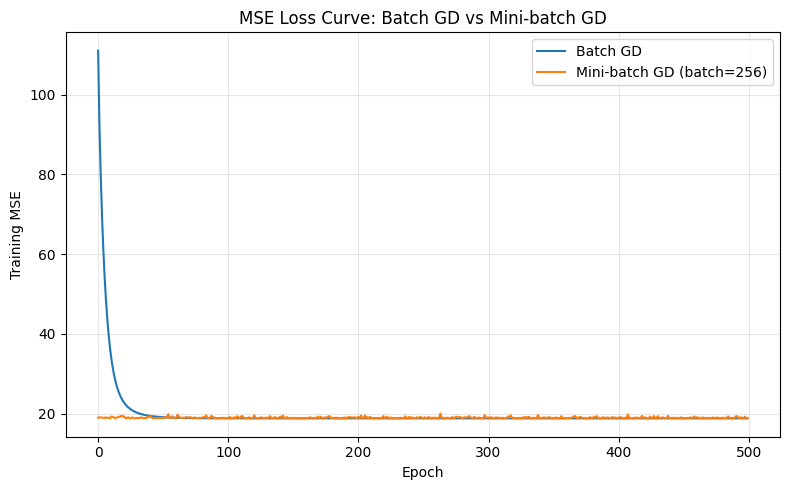

In [23]:
# ============================================================
# STEP 18: LOSS CURVE
# ============================================================

# Create graph
plt.figure(figsize=(8, 5))

# Plot Batch GD loss
plt.plot(
    loss_history_gd,
    label="Batch GD"
)

# Plot Mini-Batch GD loss
plt.plot(
    loss_history_mb,
    label="Mini-batch GD (batch=256)"
)

# X-axis label
plt.xlabel("Epoch")

# Y-axis label
plt.ylabel("Training MSE")

# Graph title
plt.title(
    "MSE Loss Curve: Batch GD vs Mini-batch GD"
)

# Show legend
plt.legend()

# Show grid
plt.grid(alpha=0.3)

# Adjust layout
plt.tight_layout()

# Save graph
plt.savefig(
    "loss_curve.png",
    dpi=150
)

# Display graph
plt.show()

In [24]:
# ============================================================
# STEP 19: FINAL COMPARISON
# ============================================================

print("\n=== RMSE Comparison ===")

# Print table heading
print(
    f"{'Method':<20}"
    f"{'Test RMSE':>12}"
)

# Batch GD
print(
    f"{'Batch GD':<20}"
    f"{rmse_gd:>12.4f}"
)

# Mini-Batch GD
print(
    f"{'Mini-batch GD':<20}"
    f"{rmse_mb:>12.4f}"
)

# sklearn Linear Regression
print(
    f"{'sklearn LinearReg':<20}"
    f"{rmse_sklearn:>12.4f}"
)


=== RMSE Comparison ===
Method                 Test RMSE
Batch GD                  4.4105
Mini-batch GD             4.4190
sklearn LinearReg         4.4105
